### React Dashboard in Colab: Limitations and Approach

Creating a full-fledged React dashboard with dynamic charts and backend data fetching directly runnable within a Colab notebook is not feasible, as Colab is primarily a Python environment for data science and machine learning, not for full-stack web development.

However, I can demonstrate the core components in Python:

1.  **Data Generation**: Simulate daily activity data.
2.  **Data Processing (Decryption)**: Show a conceptual function for decrypting data.
3.  **Visualization**: Create charts for daily activity trends using Python libraries like `pandas`, `matplotlib`, and `seaborn`.
4.  **Conceptual Backend**: Explain how a React frontend would interact with a Python backend serving this processed data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta, date

# Set a random seed for reproducibility
np.random.seed(42)

### 1. Simulate Daily Activity Data

Let's generate some dummy daily activity data. This data will be in an 'encrypted' format initially to simulate the need for decryption.

In [2]:
# Generate dates for the last 30 days
end_date = date.today()
start_date = end_date - timedelta(days=29)
dates = [start_date + timedelta(days=i) for i in range(30)]

# Generate dummy 'encrypted' activity data
# For simplicity, 'encrypted' data will be a string representation of numbers
# that need to be converted back to integers after 'decryption'.
encrypted_logins = [str(int(100 + 50 * np.sin(i / 5) + 20 * np.random.randn())) for i in range(30)]
encrypted_pageviews = [str(int(500 + 200 * np.sin(i / 7) + 50 * np.random.randn())) for i in range(30)]
encrypted_purchases = [str(int(10 + 5 * np.sin(i / 3) + 2 * np.random.randn())) for i in range(30)]

data = {
    'date': dates,
    'encrypted_logins': encrypted_logins,
    'encrypted_pageviews': encrypted_pageviews,
    'encrypted_purchases': encrypted_purchases
}
df = pd.DataFrame(data)

print("Simulated Encrypted Data:")
display(df.head())

Simulated Encrypted Data:


,date,encrypted_logins,encrypted_pageviews,encrypted_purchases
0,2026-03-18,109,469,9
1,2026-03-19,107,621,11
2,2026-03-20,132,555,10
3,2026-03-21,158,530,11
4,2026-03-22,131,649,16


### 2. Conceptual Data Decryption Function

In a real-world scenario, this would involve complex cryptographic operations. For demonstration, we'll simulate 'decryption' by simply converting the string representations back to integers. This function would reside on your backend.

_Note: This is a placeholder for actual decryption. Real decryption would involve keys, algorithms (e.g., AES), and secure handling._

In [3]:
def decrypt_data_field(encrypted_string_value):
    """
    A conceptual function to 'decrypt' a single data point.
    In a real system, this would involve actual decryption logic.
    """
    try:
        return int(encrypted_string_value)
    except ValueError:
        return np.nan # Handle cases where conversion fails

# Apply the 'decryption' to the DataFrame
df['logins'] = df['encrypted_logins'].apply(decrypt_data_field)
df['pageviews'] = df['encrypted_pageviews'].apply(decrypt_data_field)
df['purchases'] = df['encrypted_purchases'].apply(decrypt_data_field)

# Drop the encrypted columns if they are no longer needed
df_decrypted = df.drop(columns=['encrypted_logins', 'encrypted_pageviews', 'encrypted_purchases'])

print("Decrypted Data:")
display(df_decrypted.head())

Decrypted Data:


,date,logins,pageviews,purchases
0,2026-03-18,109,469,9
1,2026-03-19,107,621,11
2,2026-03-20,132,555,10
3,2026-03-21,158,530,11
4,2026-03-22,131,649,16


### 3. Visualize Daily Activity Trends (Python Charts)

Now, let's create charts to visualize the daily activity trends using `matplotlib` and `seaborn`. These charts demonstrate what you might want to display in your React dashboard, but rendered here in Python.

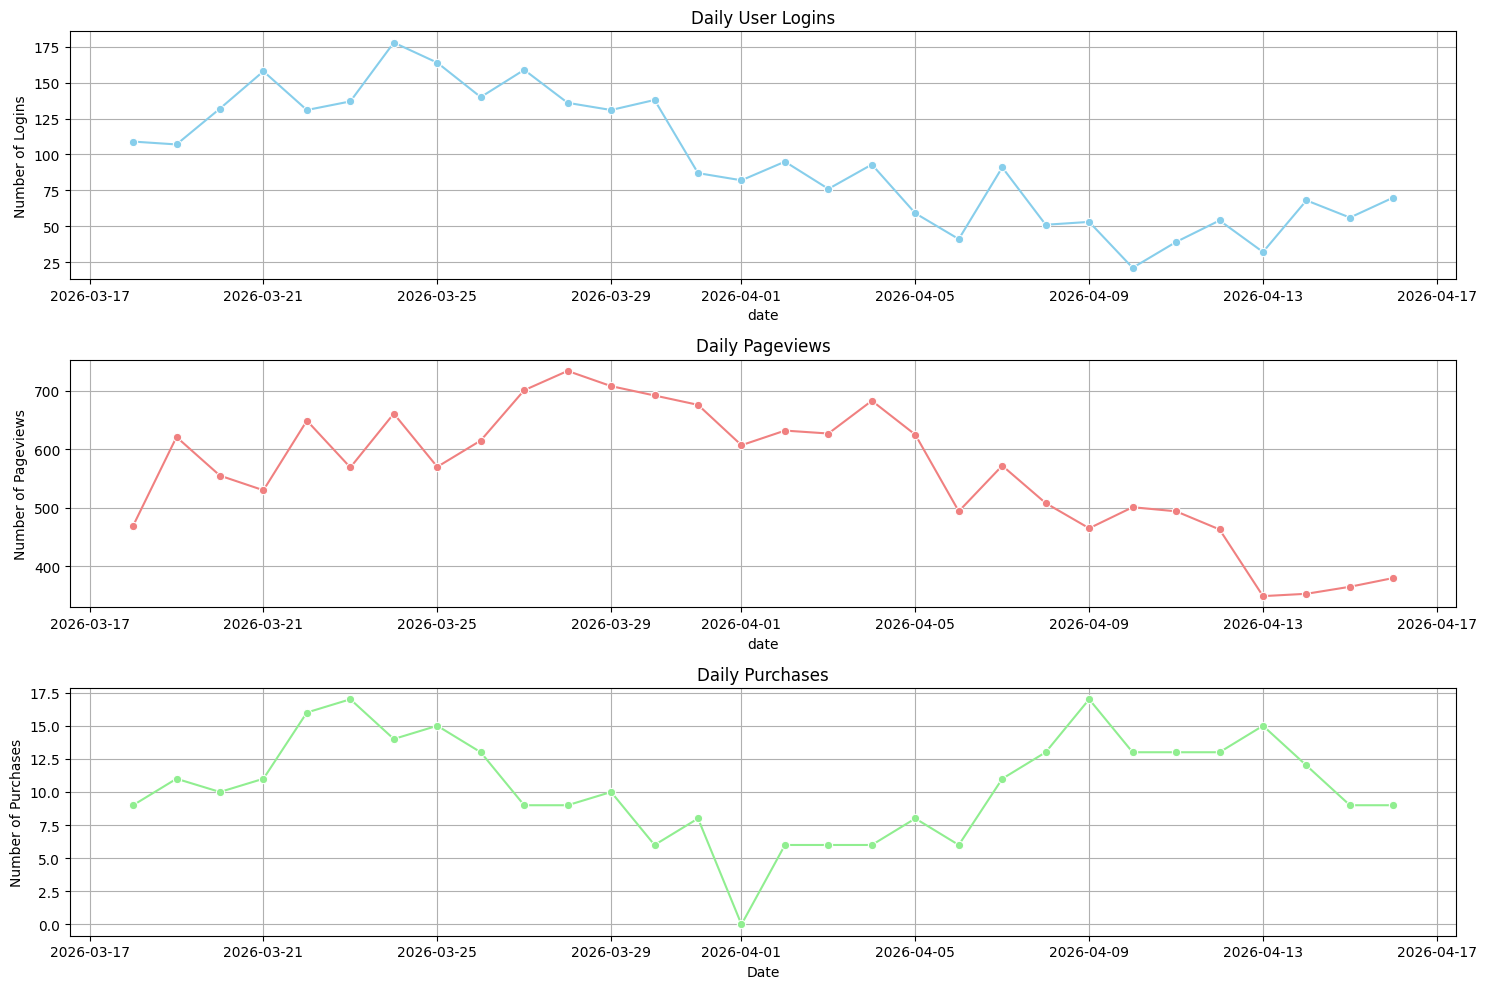

In [4]:
df_decrypted['date'] = pd.to_datetime(df_decrypted['date'])
df_decrypted = df_decrypted.set_index('date')

plt.figure(figsize=(15, 10))

# Plot daily logins
plt.subplot(3, 1, 1)
sns.lineplot(data=df_decrypted, x=df_decrypted.index, y='logins', marker='o', color='skyblue')
plt.title('Daily User Logins')
plt.ylabel('Number of Logins')
plt.grid(True)

# Plot daily pageviews
plt.subplot(3, 1, 2)
sns.lineplot(data=df_decrypted, x=df_decrypted.index, y='pageviews', marker='o', color='lightcoral')
plt.title('Daily Pageviews')
plt.ylabel('Number of Pageviews')
plt.grid(True)

# Plot daily purchases
plt.subplot(3, 1, 3)
sns.lineplot(data=df_decrypted, x=df_decrypted.index, y='purchases', marker='o', color='lightgreen')
plt.title('Daily Purchases')
plt.ylabel('Number of Purchases')
plt.xlabel('Date')
plt.grid(True)

plt.tight_layout()
plt.show()

### 4. Conceptual Backend & React Frontend Integration

To build your React dashboard, you would typically follow these steps:

1.  **Python Backend (e.g., Flask/FastAPI)**: Create a Python web server that exposes API endpoints.
    *   One endpoint (`/api/daily_activity`) could serve the `df_decrypted` data as JSON.
    *   The `decrypt_data_field` function would be part of this backend, performing actual decryption before sending the data.

    ```python
    # Example using Flask (conceptual, not runnable in Colab directly for web serving)
    # from flask import Flask, jsonify
    # app = Flask(__name__)
    # @app.route('/api/daily_activity')
    # def get_daily_activity():
    #     # ... generate and decrypt df_decrypted ...
    #     return jsonify(df_decrypted.reset_index().to_dict(orient='records'))
    # if __name__ == '__main__':
    #     app.run(debug=True)
    ```

2.  **React Frontend**: Create a React application using tools like Create React App or Vite.
    *   **Data Fetching**: Use `fetch` or `axios` in your React components to call the backend API endpoint (`/api/daily_activity`).
    *   **State Management**: Store the fetched data in your React component's state.
    *   **Chart Libraries**: Use React-compatible charting libraries (e.g., `Chart.js` with `react-chartjs-2`, `Recharts`, `Nivo`, `Tremor`) to render the `logins`, `pageviews`, and `purchases` trends.
    *   **Dashboard Layout**: Design your dashboard layout using CSS frameworks or UI libraries (e.g., Material-UI, Ant Design, Chakra UI).